# Notebook n°8: Milestone 3 (M3) Multivariate Audio↔OEP Coupling (CCA + PLS)

**Pipeline stage:** Milestone 3 (M3), the multivariate follow-up to the pairwise correlations of notebook n°3. Instead of one acoustic feature against one OEP feature, we ask which *combination* of audio features couples to which *combination* of respiratory features (CCA), and whether the whole audio block predicts the rib-cage share `%RC` (PLS).

**Script reproduced:** `scripts/analyze_multivariate_coupling.py`.

Audio block (16): `f0`, `energy`, `spectral_centroid`, `mfcc_0..12`. OEP block (3): `delta_vcw`, `flow_cw`, `pct_rc`. Voiced frames from sustained phonation are z-scored *within subject* (so the coupling is the calibration-free within-subject signal), the glissando `a_7` is excluded, and every number is cross-validated by subject.

> ⚠️ Requires scikit-learn.

**Summary.**\
Moving beyond pairwise Pearson (the supervisors' multivariate ask): CCA finds the audio-combination and OEP-combination with maximal correlation; PLS predicts `%RC` from the whole audio block. Both run on within-subject z-scored voiced frames from sustained phonation (glissando `a_7` excluded), per demographic stratum, cross-validated by subject.\
The audio↔OEP coupling is real but low-dimensional: first canonical correlation ≈ 0.39 under subject-CV, barely above the best single pair (energy↔volume ≈ 0.36), and carried by spectral level (MFCC-0, energy), not pitch.\
Audio → %RC prediction is weakly positive (CV R² ≈ 0.06, up to ≈ 0.10 in some strata).\
A colleague's leakage-safe pipelines (§4) sharpen this: per recording, out-of-sample, the coupling vanishes (CCA r ≈ 0, surrogate not significant) and prediction is negative (D-PLS R² ≈ −0.12). The link is a population-average association, not an instantaneous predictor; the only positive predictive result is the FRC-state decode of notebook n°6.

## 0. Setup
Build the within-subject z-scored frame matrix once (sustained phonation, glissando excluded).

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

from analyze_multivariate_coupling import (build_frames, cca_eval, pls_cv,
                                           stratum_index, AUDIO, OEP, STRATA_ORDER)
from analyze_l3_stratified import load_metadata
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

META = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
PAIRED = REPO / "data_target" / "healthy_subjects" / "paired"
F = build_frames(PAIRED, load_metadata(META))
print(f"{len(F):,} voiced frames (sustained, a_7 excluded) | {F['subject_id'].nunique()} subjects")

105,918 voiced frames (sustained, a_7 excluded) | 37 subjects


## 1. CCA: symmetric audio↔OEP coupling, per stratum
Sustained phonation, within-subject z-scored. First canonical correlation, in-sample vs subject-held-out CV.

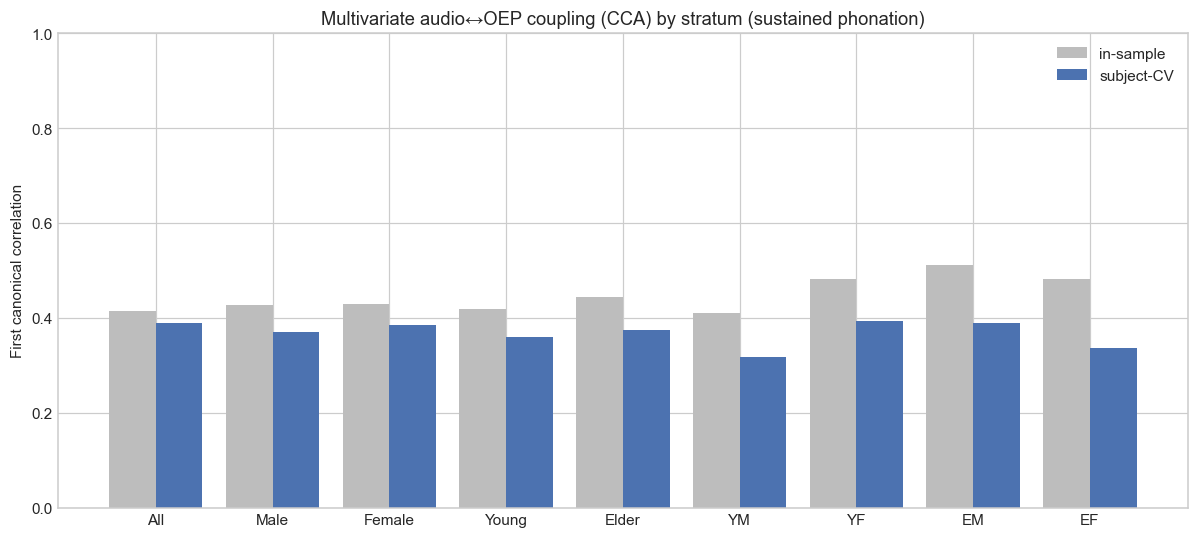

subject-CV canonical r: {'All': 0.388, 'Male': 0.37, 'Female': 0.385, 'Young': 0.36, 'Elder': 0.374, 'YM': 0.318, 'YF': 0.394, 'EM': 0.39, 'EF': 0.337}


In [2]:
cca_res = {s: cca_eval(F, stratum_index(F, s)) for s in STRATA_ORDER}
cca_res = {s: r for s, r in cca_res.items() if r is not None}
strata = list(cca_res); x = np.arange(len(strata)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, [cca_res[s]['r_in'] for s in strata], w, label='in-sample', color='#bdbdbd')
ax.bar(x + w/2, [cca_res[s]['r_cv'] for s in strata], w, label='subject-CV', color='#4c72b0')
ax.set_xticks(x); ax.set_xticklabels(strata); ax.set_ylim(0, 1)
ax.set_ylabel('First canonical correlation')
ax.set_title('Multivariate audio↔OEP coupling (CCA) by stratum (sustained phonation)')
ax.legend(); plt.tight_layout(); plt.show()
print('subject-CV canonical r:', {s: round(cca_res[s]['r_cv'], 3) for s in strata})

**Observations:**\
Sustained phonation (`a_2`, `a_3`, vowels, `r`); glissando `a_7` excluded; voiced frames z-scored within subject.\
The first canonical correlation between the audio and OEP blocks is ≈ 0.39 under subject-held-out CV (in-sample ≈ 0.41), so the multivariate coupling is real and does not overfit.\
It is only modestly above the best single pair (energy↔volume ≈ 0.36): the shared audio↔respiratory variance is low-dimensional, not a hidden high-dimensional link.\
The coupling is fairly uniform across strata (CV r ≈ 0.32 to 0.39); the small cells inflate in-sample but settle on CV.

## 2. Which audio features carry the coupling?
Loading of each audio feature on the first canonical variate (correlation with the audio canonical score).

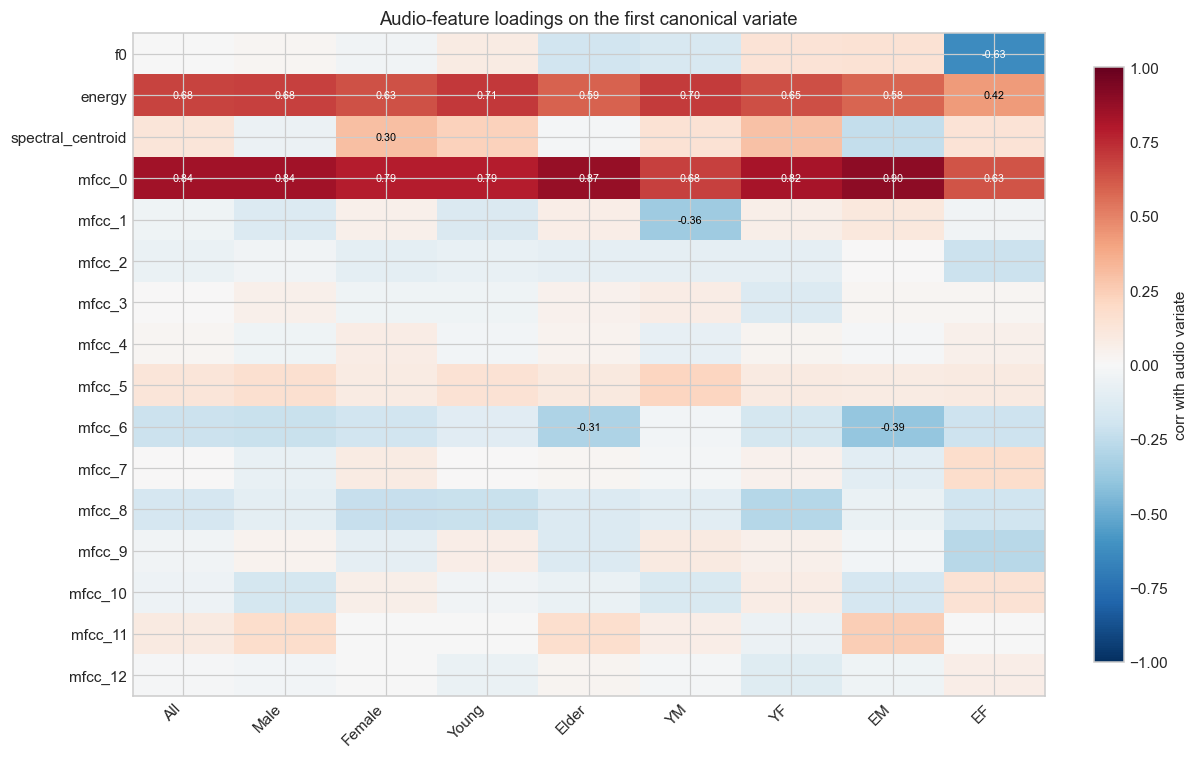

OEP loadings (All): {'delta_vcw': 0.99, 'flow_cw': -0.08, 'pct_rc': -0.64}


In [3]:
piv = pd.DataFrame({s: {f: cca_res[s]['audio_loadings'][f] for f in AUDIO} for s in strata}).reindex(AUDIO)
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha='right')
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if abs(v) > 0.3:
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 0.55 else 'black')
ax.set_title('Audio-feature loadings on the first canonical variate')
fig.colorbar(im, ax=ax, fraction=0.03, label='corr with audio variate')
plt.tight_layout(); plt.show()
# OEP side, All stratum
print('OEP loadings (All):', {k: round(v, 2) for k, v in cca_res['All']['oep_loadings'].items()})

**Observations:**\
Sustained phonation, within-subject z-scored.\
The audio canonical variate is dominated by **MFCC-0 (≈ +0.84)** and **energy (≈ +0.68)**: overall spectral level / loudness.\
`f0` and the higher MFCCs contribute little, and the pattern is consistent across strata.\
So the audio side that couples to respiration is loudness, not pitch, the same carrier the FRC-state classifier found in notebook n°6.

## 3. PLS: predict %RC from the audio block, per stratum
Leave-subjects-out CV R² for the whole audio block predicting `%RC` (the multivariate version of notebook n°5's per-feature Ridge).

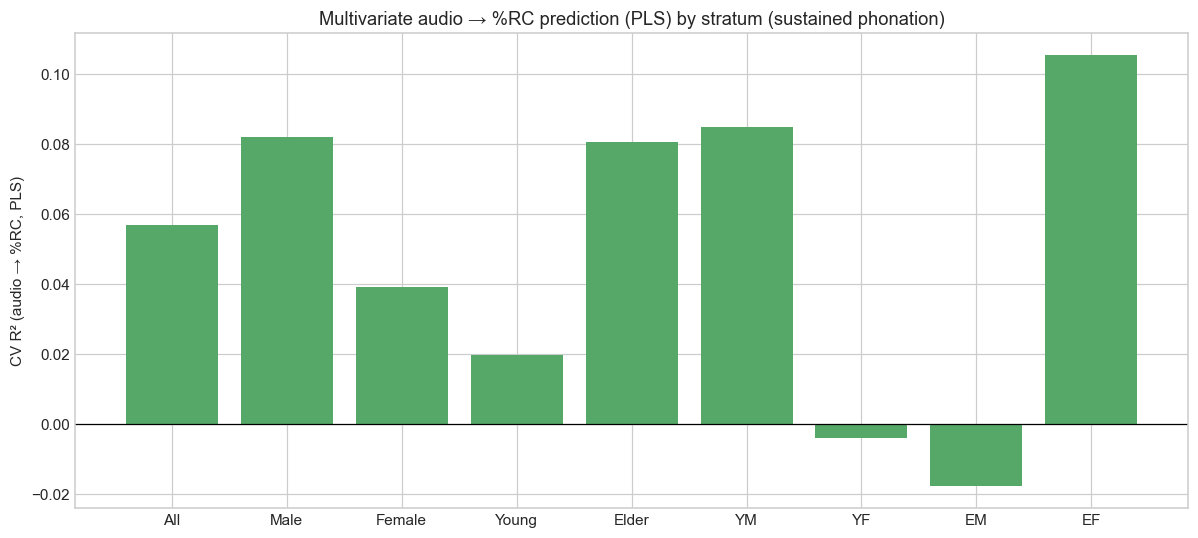

audio → %RC CV R²: {'All': 0.057, 'Male': 0.082, 'Female': 0.039, 'Young': 0.02, 'Elder': 0.081, 'YM': 0.085, 'YF': -0.004, 'EM': -0.018, 'EF': 0.105}


In [4]:
pls_res = {s: pls_cv(F, stratum_index(F, s)) for s in STRATA_ORDER}
pls_res = {s: r for s, r in pls_res.items() if r is not None}
ps = list(pls_res)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(ps)), [pls_res[s]['r2_cv'] for s in ps], color='#55a868')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(ps))); ax.set_xticklabels(ps)
ax.set_ylabel('CV R² (audio → %RC, PLS)')
ax.set_title('Multivariate audio → %RC prediction (PLS) by stratum (sustained phonation)')
plt.tight_layout(); plt.show()
print('audio → %RC CV R²:', {s: round(pls_res[s]['r2_cv'], 3) for s in ps})

**Observations:**\
Sustained phonation; audio block → `%RC`; leave-subjects-out CV.\
Multivariate PLS predicts within-subject `%RC` weakly but positively (CV R² ≈ 0.06 overall, up to ≈ 0.10 in elderly females, young males, and the elderly/male aggregates).\
This edges out the per-feature Ridge of notebook n°5 (which was negative), so combining features helps a little.\
It is near-chance in young females and elderly males; continuous `%RC` stays hard to predict frame-by-frame, consistent with notebook n°5.

## 4. Robust out-of-sample validation (colleague pipelines)
A colleague added two leakage-safe pipelines (`scripts/robust_pca_cca_pipeline.py`,
`scripts/robust_predictive_dpls_pipeline.py`) that stress-test the coupling **per recording**:
PCA before CCA (regularisation), **time-series cross-validation** (train on earlier frames, test on
later ones), **phase-randomized surrogates**, and for D-PLS a **nested** CV with leakage-safe scaling
and a VIP stability bootstrap. They write to `data_target/healthy_subjects/figures/multivariate/`.
The cells below read those exported results.

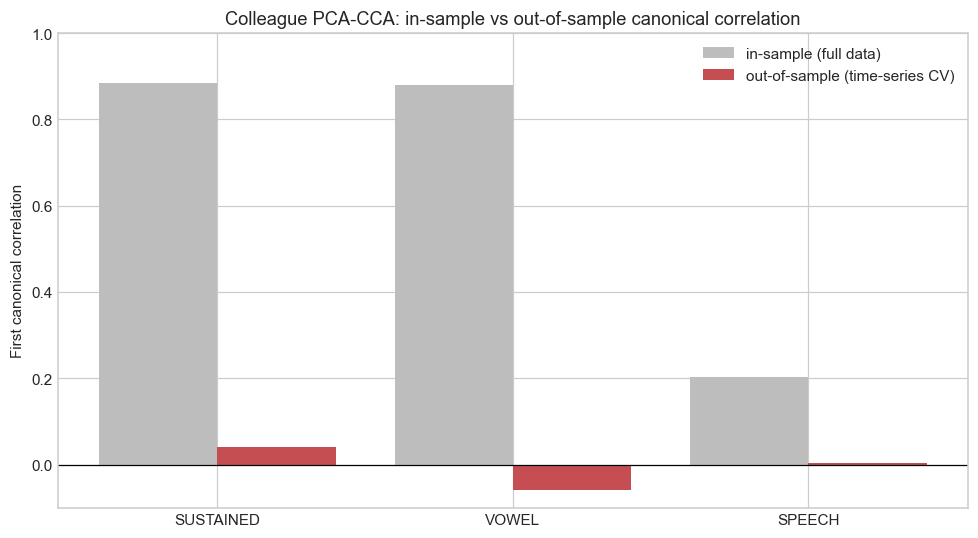

               cca_r_full  cca_r_cv_mean
category_name                           
SUSTAINED           0.883          0.041
VOWEL               0.879         -0.059
SPEECH              0.204          0.003


In [5]:
import pandas as pd
MV = REPO / "data_target" / "healthy_subjects" / "figures" / "multivariate"
cca_csv = MV / "pca_cca" / "PCA_CCA_Subject_Results_healthy_subjects.csv"
if not cca_csv.exists():
    print("Run scripts/robust_pca_cca_pipeline.py first (writes to data_target/.../multivariate/pca_cca).")
else:
    cca = pd.read_csv(cca_csv, sep=';')
    g = cca.groupby('category_name')[['cca_r_full', 'cca_r_cv_mean']].mean()
    g = g.reindex([c for c in ['SUSTAINED', 'VOWEL', 'SPEECH'] if c in g.index])
    x = np.arange(len(g)); w = 0.4
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, g['cca_r_full'], w, label='in-sample (full data)', color='#bdbdbd')
    ax.bar(x + w/2, g['cca_r_cv_mean'], w, label='out-of-sample (time-series CV)', color='#c44e52')
    ax.axhline(0, color='black', lw=0.8); ax.set_ylim(-0.1, 1.0)
    ax.set_xticks(x); ax.set_xticklabels(g.index); ax.set_ylabel('First canonical correlation')
    ax.set_title('Colleague PCA-CCA: in-sample vs out-of-sample canonical correlation')
    ax.legend(); plt.tight_layout(); plt.show()
    print(g.round(3))

**Observations:**\
Colleague PCA-CCA pipeline: per-recording PCA→CCA, time-series cross-validation, phase-randomized surrogates.\
In-sample canonical correlation is high (0.28 to 0.88), but out-of-sample it collapses to about zero in every task category (SUSTAINED 0.04, SPEECH 0.003, VOWEL −0.06).\
The speech surrogate test is not significant (p = 0.51).\
So the high in-sample value is overfitting: within one recording the canonical relationship does not carry from earlier to later frames.

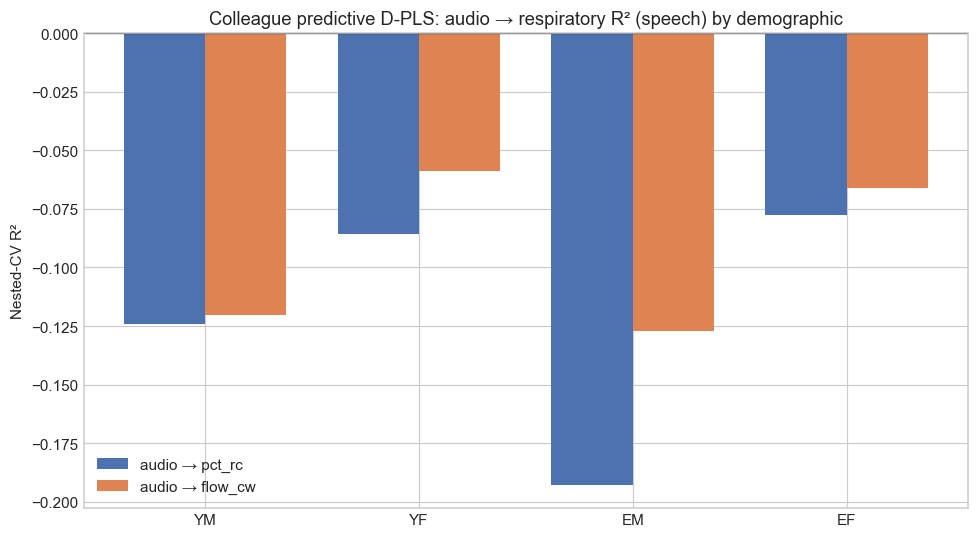

 target demographic   mean   std
 pct_rc          EF -0.077 0.073
 pct_rc          EM -0.193 0.120
 pct_rc          YF -0.086 0.055
 pct_rc          YM -0.124 0.098
flow_cw          EF -0.066 0.047
flow_cw          EM -0.127 0.114
flow_cw          YF -0.059 0.026
flow_cw          YM -0.120 0.109


In [6]:
dp = MV / "predictive_dpls"
frames = []
for tgt in ['pct_rc', 'flow_cw']:
    f = dp / f"Predictive_R2_healthy_subjects_{tgt}.csv"
    if f.exists():
        d = pd.read_csv(f, sep=';'); d['target'] = tgt; frames.append(d)
if not frames:
    print("Run scripts/robust_predictive_dpls_pipeline.py first.")
else:
    R = pd.concat(frames, ignore_index=True); demos = ['YM', 'YF', 'EM', 'EF']
    x = np.arange(len(demos)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    for k, (tgt, col) in enumerate([('pct_rc', '#4c72b0'), ('flow_cw', '#dd8452')]):
        s = R[R.target == tgt].set_index('demographic').reindex(demos)
        ax.bar(x + (k - 0.5)*w, s['mean'], w, label=f'audio → {tgt}', color=col)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(demos); ax.set_ylabel('Nested-CV R²')
    ax.set_title('Colleague predictive D-PLS: audio → respiratory R² (speech) by demographic')
    ax.legend(); plt.tight_layout(); plt.show()
    print(R[['target', 'demographic', 'mean', 'std']].round(3).to_string(index=False))

**Observations:**\
Colleague predictive D-PLS: lags and derivatives, nested time-series CV, leakage-safe scaling, VIP bootstrap; connected speech.\
Out-of-sample R² is negative for both targets in every demographic (audio → %RC ≈ −0.12, audio → flow_cw ≈ −0.09).\
The nominal top predictor is f0, but it is unstable (probability of VIP > 1 ≈ 0.51).\
Audio does not predict the instantaneous respiratory state within a recording.

## 5. Two methods, one conclusion
The two approaches ask different questions, which is why the numbers differ.

| aspect | this notebook (§1 to §3) | colleague pipelines (§4) |
|--------|--------------------------|--------------------------|
| unit and CV | pooled frames, leave-subjects-out | per recording, time-series split |
| standardisation | within-subject z-score | absolute and dynamic (differenced) |
| regularisation | none (16 features) | PCA before CCA; nested CV for D-PLS |
| extra rigour | subject hold-out | phase-randomized surrogates, VIP bootstrap |
| CCA result | canonical r ≈ 0.39 | out-of-sample r ≈ 0 (in-sample 0.3 to 0.9) |
| prediction | PLS audio→%RC R² ≈ 0.06 | D-PLS R² ≈ −0.12 |

The pooled analysis measures the cross-subject **average** coupling: on average louder phonation goes with more chest-wall engagement, and that average holds across held-out subjects (r ≈ 0.39, loudness-carried).
The colleague's per-recording tests measure **temporal predictivity**: can the relationship learned on earlier frames predict later frames of the same recording? It cannot (r ≈ 0, surrogate not significant, D-PLS R² negative).
Both are correct. The audio and respiratory signals share a weak population-level association, not a reliable instantaneous mapping. This confirms the do-EDA-before-ML verdict: there is no exploitable frame-level predictive signal, so the only positive predictive result stays the binary FRC-state decode of notebook n°6.

## Recap
Two complementary multivariate views converge. The pooled, within-subject analysis (§1 to §3) finds a real but low-dimensional audio↔respiratory coupling (canonical r ≈ 0.39) carried by loudness / spectral level, with audio→%RC only weakly predictive (CV R² ≈ 0.06). The colleague's leakage-safe pipelines (§4) show the coupling does not survive out-of-sample within a recording: PCA-CCA canonical correlation falls from 0.3 to 0.9 in-sample down to ≈ 0 out-of-sample (surrogate not significant), and predictive D-PLS gives negative R² for both %RC and flow.

Practical consequence for M3/M4: the readable respiratory signal in voice is a weak, population-average loudness effect, not an instantaneous predictor. The defensible deliverable remains the binary FRC-state decode of notebook n°6 (≈ 0.70 per frame, ≈ 0.96 at the breath scale). Richer non-linear models are unlikely to clear this ceiling.

To regenerate everything:

```bash
python scripts/analyze_multivariate_coupling.py --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir data_target/healthy_subjects/M3_multivariate
python scripts/robust_pca_cca_pipeline.py
python scripts/robust_predictive_dpls_pipeline.py
```